In [117]:
## Import Libraries
import os
import pandas as pd
import numpy as np
import statsmodels.api as sm
import scipy.optimize as sc
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
chunkID = 2
if chunkID == 1:
    stations = np.arange(1,21)
    # Define Layers
    layers = np.array([25.5, 26.0, 26.55,27.2], dtype=float)  # in sigma0
elif chunkID == 2:
    stations = np.arange(21,40)
    # Define Layers
    layers = np.array([25.75, 26.35, 26.55,27.2], dtype=float)  # in sigma0
elif chunkID == 3:
    stations = np.arange(40,44)
    # Define Layers
    layers = np.array([26.0, 26.55,27.4], dtype=float)  # in sigma0
elif chunkID == 4:
    stations = np.arange(44,48)
    # Define Layers
    layers = np.array([26.0, 26.55,27.4], dtype=float)  # in sigma0
elif chunkID == 5:
    stations = np.arange(48,57)
    # Define Layers
    layers = np.array([25.99, 26.25, 26.55,27.2], dtype=float)  # in sigma0\
elif chunkID == 6:
    stations = np.arange(58,71)
    # Define Layers
    layers = np.array([25.99, 26.25, 26.55,27.2], dtype=float)  # in sigma0

In [3]:
def quickplot(xvar, yvar, regression, xlabel, ylabel, lower_boundary, upper_boundary):
    fig, ax = plt.subplots(1, 1, figsize=(3, 3))
    ax.scatter(xvar, yvar)
    xfit = np.linspace(xvar.min(), xvar.max())
    ax.plot(xfit, xfit * regression.params[1] + regression.params[0], color="k")
    textstr = f"$R^2$={regression.rsquared:.2}\np={regression.pvalues[1]:.2}"
    ax.text(0.05, 0.8, textstr, transform = ax.transAxes)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(fr'$\sigma_{{\theta}}${lower_boundary}-{upper_boundary}')
    plt.tight_layout()
    plt.savefig(f"figures/chunk{chunkID}/{lower_boundary}-{upper_boundary}_{ylabel}vs{xlabel}.pdf",)
    plt.show()

In [30]:
# Set Directory
#fpath = "output/OM_variations/experimental2/{}"
fpath = 'output/OM_variations/anderson/{}'

# Import Data
data = pd.read_csv("data_clean.csv")
data = data.dropna()
R = np.loadtxt(fpath.format("R.txt"), delimiter=",")
Rsolve = R[[0,1,3,4,5]] # remove row for NH4

# Define Inputs
divider = 1#2  # Number of sublayers in each layer
K = 10000  # Number of Iterations for Monte Carlo Error Propagation

### Data Preparation ###
# Select Stations
idx_station = np.where(np.isin(data["Station"], stations))

# Save Data Vectors
rho = np.array(data["rho"])[idx_station]  # kg/m3
sigma0 = np.array(data["sigma0"])[idx_station]  # kg/m3
DIC = np.array(data["DIC"])[idx_station]  # umol/kg
DIP = np.array(data["DIP"])[idx_station]  # umol/kg
NO2 = np.array(data["NO2"])[idx_station]  # umol/kg
NO3 = np.array(data["NO3"])[idx_station]  # umol/kg
#NH4 = np.array(data["NH4"])[idx_station]  # umol/kg
Nstar = np.array(data["Nstar"])[idx_station]  # umol/kg
TA = np.array(data["TA"])[idx_station]  # umol/kg
pH = np.array(data["pH"])[idx_station]
O2 = np.array(data["O2"])[idx_station]  # umol/kg

# divide layers up into sublayers
sl = np.zeros((len(layers) - 1, divider + 1))
for i in np.arange(0, len(layers) - 1):
    sl[i,] = np.linspace(layers[i], layers[i + 1], divider + 1)
sublayers = np.unique(sl)

### Robust Linear Regression ###
# Create Results Arrays
fitting_NO3 = np.zeros((len(sublayers) - 1, 4))
fitting_NO2 = np.zeros((len(sublayers) - 1, 4))
#fitting_NH4 = np.zeros((len(sublayers) - 1, 4))
fitting_Nstar = np.zeros((len(sublayers) - 1, 4))
fitting_TA = np.zeros((len(sublayers) - 1, 4))
fitting_DIC = np.zeros((len(sublayers) - 1, 4))

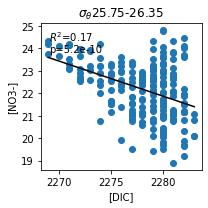

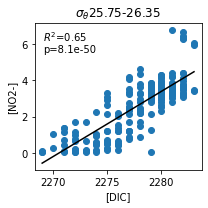

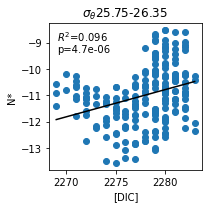

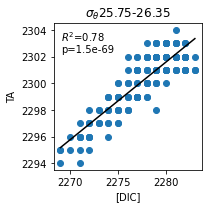

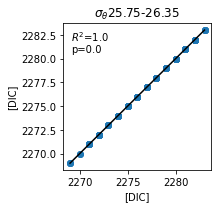

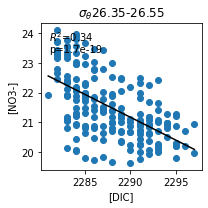

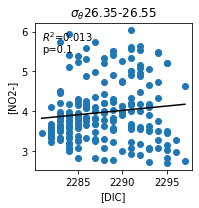

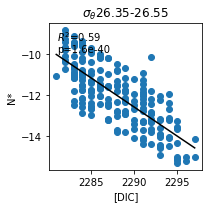

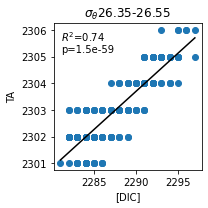

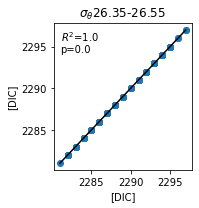

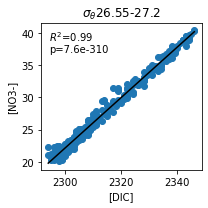

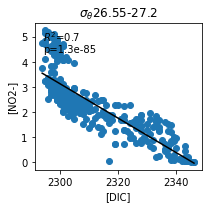

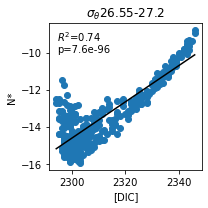

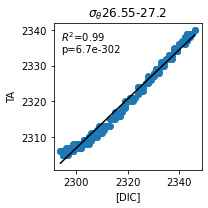

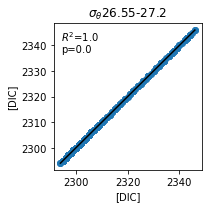

In [7]:
# Run Robost Linear Regression
for i in np.arange(0, len(sublayers) - 1):
    lower_boundary = sublayers[i]
    upper_boundary = sublayers[i + 1]
    idx_layer = np.where((sigma0 >= lower_boundary) & (sigma0 <= upper_boundary))
    if chunkID == 5:
        idx_layer = np.where((sigma0 >= lower_boundary) & (sigma0 <= upper_boundary)
            & (DIC < 2300))

    # Robust Regression
    if len(DIC[idx_layer]) > 0:
        xx = sm.add_constant(DIC[idx_layer])
        rf_NO3 = sm.OLS(NO3[idx_layer], xx, 
            #M=sm.robust.norms.HuberT()
            ).fit()
        rf_NO2 = sm.OLS(NO2[idx_layer], xx, 
            #M=sm.robust.norms.HuberT()
            ).fit()
        #rf_NH4 = sm.RLM(NH4[idx_layer], xx, M=sm.robust.norms.HuberT()).fit()
        rf_Nstar = sm.OLS(Nstar[idx_layer], xx, 
            #M=sm.robust.norms.HuberT()
            ).fit()
        rf_TA = sm.OLS(TA[idx_layer], xx, 
            #M=sm.robust.norms.HuberT()
            ).fit()
        rf_DIC = sm.OLS(DIC[idx_layer], xx, 
            #M=sm.robust.norms.HuberT()
            ).fit()

        # Save Results
        fitting_NO3[i, :] = np.array(
            [rf_NO3.params[1], rf_NO3.bse[1], rf_NO3.params[0], rf_NO3.bse[0]]
        )
        fitting_NO2[i, :] = np.array(
            [rf_NO2.params[1], rf_NO2.bse[1], rf_NO2.params[0], rf_NO2.bse[0]]
        )
        #fitting_NH4[i, :] = np.array(
        #    [rf_NH4.params[1], rf_NH4.bse[1], rf_NH4.params[0], rf_NH4.bse[0]]
        #)
        fitting_Nstar[i, :] = np.array(
            [rf_Nstar.params[1], rf_Nstar.bse[1], rf_Nstar.params[0], rf_Nstar.bse[0]]
        )
        fitting_TA[i, :] = np.array(
            [rf_TA.params[1], rf_TA.bse[1], rf_TA.params[0], rf_TA.bse[0]]
        )
        fitting_DIC[i, :] = np.array(
            [rf_DIC.params[1], rf_DIC.bse[1], rf_DIC.params[0], rf_DIC.bse[0]]
        )

        quickplot(DIC[idx_layer], NO3[idx_layer], rf_NO3, 
            "[DIC]", "[NO3-]", lower_boundary, upper_boundary)
        quickplot(DIC[idx_layer], NO2[idx_layer], rf_NO2, 
            "[DIC]", "[NO2-]", lower_boundary, upper_boundary)
        quickplot(DIC[idx_layer], Nstar[idx_layer], rf_Nstar, 
            "[DIC]", "N*", lower_boundary, upper_boundary)
        quickplot(DIC[idx_layer], TA[idx_layer], rf_TA, 
            "[DIC]", "TA", lower_boundary, upper_boundary)
        quickplot(DIC[idx_layer], DIC[idx_layer], rf_DIC, 
            "[DIC]", "[DIC]", lower_boundary, upper_boundary)

    else:
        print(f"no data {sublayers[i]}-{sublayers[i + 1]}")

In [8]:
# Save Slopes
slopes_mean = np.array(
    [
        fitting_NO3[:, 0].T,
        fitting_NO2[:, 0].T,
        #fitting_NH4[:, 0].T,
        fitting_Nstar[:, 0].T,
        fitting_TA[:, 0].T,
        fitting_DIC[:, 0].T,
    ]
).T
slopes_se = np.array(
    [
        fitting_NO3[:, 1],
        fitting_NO2[:, 1],
        #fitting_NH4[:, 1],
        fitting_Nstar[:, 1],
        fitting_TA[:, 1],
        fitting_DIC[:, 1],
    ]
).T

In [15]:
slopes_mean

array([[-0.15686113,  0.36126145,  0.10342548,  0.5848791 ,  1.        ],
       [-0.15473987,  0.0219729 , -0.2839588 ,  0.2867349 ,  1.        ],
       [ 0.39256557, -0.06880607,  0.09753147,  0.6934027 ,  1.        ]])

In [13]:
fitting_NO2[:,0]

array([ 0.36126145,  0.0219729 , -0.06880607])

In [40]:
fpath = 'output/OM_variations/anderson/{}'
R = np.loadtxt(fpath.format("R.txt"), delimiter=",")
Rsolve = R[[0,1,3,4,5]] # remove row for NH4

Rdf = pd.DataFrame(Rsolve, columns = ["DNRN","denit","anammox","nitrox","CaCO3 diss"])
Rdf["tracer"] = ["NO3", "NO2", "N*", "TA", "DIC"]

Rdf.set_index("tracer", inplace = True)
Rdf

,DNRN,denit,anammox,nitrox,CaCO3 diss
tracer,,,,,
NO3,-2.226415,0.000000,2.909,46.296,0.0
NO2,2.226415,-1.484245,-12.000,-46.296,0.0
N*,0.000000,-1.484245,-18.182,0.000,0.0
TA,0.141509,1.625755,0.182,0.000,2.0
DIC,1.000000,1.000000,-1.000,-1.000,1.0


In [67]:
fpath = "output/OM_variations/experimental2/{}"
R = np.loadtxt(fpath.format("R.txt"), delimiter=",")
Rsolve = R[[0,1,3,4,5]] # remove row for NH4

Rdf = pd.DataFrame(Rsolve, columns = ["DNRN","denit","anammox","nitrox","CaCO3 diss"])
Rdf["tracer"] = ["NO3", "NO2","N*", "TA", "DIC"]

Rdf.set_index("tracer", inplace = True)
Rdf

,DNRN,denit,anammox,nitrox,CaCO3 diss
tracer,,,,,
NO3,-1.614998,0.000000,2.909,46.296,0.0
NO2,1.614998,-1.076666,-12.000,-46.296,0.0
N*,0.000000,-1.076666,-18.182,0.000,0.0
TA,0.094224,1.170890,0.182,0.000,2.0
DIC,1.000000,1.000000,-1.000,-1.000,1.0


In [72]:
slopesdf  = pd.DataFrame(slopes_mean,
                         columns = ["NO3", "NO2","N*", "TA", "DIC"])
slopesdf.reset_index().rename(columns = {"index":"sublayer"})

,sublayer,NO3,NO2,N*,TA,DIC
0,0,-0.156861,0.361261,0.103425,0.584879,1.0
1,1,-0.154740,0.021973,-0.283959,0.286735,1.0
2,2,0.392566,-0.068806,0.097531,0.693403,1.0


In [93]:
slope_iter = np.zeros((slopes_mean.shape[1]))
for i in np.arange(0,2): #len(sublayers) - 1):  # do Monte Carlo simulation for each layer
    for j in range(slopes_mean.shape[1]):  # pick a value for measured Δtracer:DIC based on normal distribution
        slope_iter[j] = np.random.normal(
            loc=slopes_mean[i, j], scale=slopes_se[i, j], size=1
        )

In [94]:
slope_iter

array([-0.17291634,  0.01846743, -0.29469104,  0.30371065,  1.        ])

In [95]:
c_temp, rnorm = sc.nnls(Rsolve, slope_iter)
c_temp

array([0.93115141, 0.01319516, 0.01542648, 0.02777813, 0.09885804])

In [96]:
0.72118468*1.614998+0*-1.076666+0*-12.0+0.03019207*-46.296+0.30900739*0

-0.23306025688936005

In [97]:
c_temp / np.sum(c_temp) 

array([0.85709086, 0.01214566, 0.01419951, 0.02556875, 0.09099521])

In [98]:
coeff_iter = c_temp / np.sum(c_temp)  # make sure X matrix sums to 1

In [100]:
cdf = pd.DataFrame(c_temp, columns = ["fraction"])
cdf["reaction"] = ["DNRN","denit","anammox","nitrox","CaCO3 diss"]
cdf.set_index("reaction")

,fraction
reaction,
DNRN,0.931151
denit,0.013195
anammox,0.015426
nitrox,0.027778
CaCO3 diss,0.098858


In [85]:
Rdf

,DNRN,denit,anammox,nitrox,CaCO3 diss
tracer,,,,,
NO3,-1.614998,0.000000,2.909,46.296,0.0
NO2,1.614998,-1.076666,-12.000,-46.296,0.0
N*,0.000000,-1.076666,-18.182,0.000,0.0
TA,0.094224,1.170890,0.182,0.000,2.0
DIC,1.000000,1.000000,-1.000,-1.000,1.0


In [101]:
abs(R[1, 2] * c_temp[2] + R[1, 1] * c_temp[1])

0.19932453777066528

In [102]:
anmx_iter = abs(R[1, 2] * c_temp[2]) / abs(R[1, 2] * c_temp[2] + R[1, 1] * c_temp[1]) * 100
anmx_iter

92.87254067247504

In [103]:
denit_iter = abs(R[1, 1] * c_temp[1]) / abs(R[1, 2] * c_temp[2] + R[1, 1] * c_temp[1])* 100
denit_iter

7.127459327524967

In [112]:
slopes_obs = slopes_mean[i,:].T
slopes_obs

array([-0.15473987,  0.0219729 , -0.2839588 ,  0.2867349 ,  1.        ])

In [113]:
slopes_est = np.dot(Rsolve, coeff_iter)
slopes_est

array([-0.15916318,  0.0169986 , -0.27125234,  0.27955456,  0.92046348])

In [115]:
residuals = slopes_obs - slopes_est
residuals

array([ 0.00442331,  0.0049743 , -0.01270647,  0.00718034,  0.07953652])

In [116]:
residuals_perc = abs(residuals) / abs(slopes_obs) * 100
residuals_perc

array([ 2.85854439, 22.63835266,  4.47475689,  2.50417324,  7.95365225])

[Text(0.5, 0, '$\\Delta$$NO_3^-$'),
 Text(1.5, 0, '$\\Delta$$NO_2^-$'),
 Text(2.5, 0, '$\\Delta$$N^*$'),
 Text(3.5, 0, '$\\Delta$$TA$'),
 Text(4.5, 0, '$\\Delta$$DIC$')]

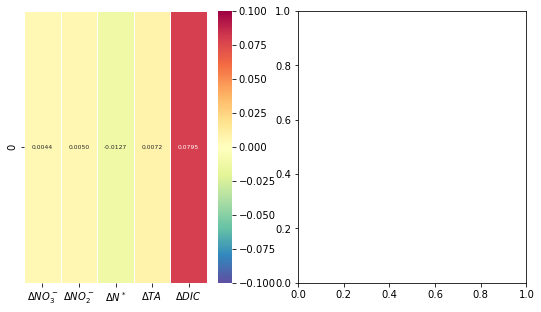

In [122]:
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 5))
hm = sns.heatmap(
    ax=ax1,
    data=np.array([residuals]),
    annot=True,
    annot_kws={"size": 6},
    fmt=".4f",
    cmap="Spectral_r",
    vmin=-0.10,
    vmax=0.10,
    linewidths=0.5,
)

hm.set_xticklabels(
    [
        "$\Delta$$NO_3^-$",
        "$\Delta$$NO_2^-$",
        #"$\Delta$$NH_4^+$",
        "$\Delta$$N^*$",
        "$\Delta$$TA$",
        "$\Delta$$DIC$",
    ]
)